<a href="https://colab.research.google.com/github/okana2ki/ML/blob/main/NN_calcu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 内積（ドット積）の計算

In [2]:
import numpy as np
X = np.array([0.3, 0.8, 1.2, 0.7])
W = np.array([1, 2, 1, 1])
B = 0.2
A = np.dot(X,W) + B
print(A)

4.0


### ReLU活性化関数の適用

ReLU (Rectified Linear Unit) は、入力が0より小さい場合は0を出力し、0より大きい場合は入力をそのまま出力する活性化関数です。数式では $f(x) = \max(0, x)$ と表されます。

In [7]:
def relu(x):
    return np.maximum(0, x)

# AにReLU活性化関数を適用
A_relu = relu(A)
print(f"ReLUを適用した後のAの値: {A_relu}")

ReLUを適用した後のAの値: 4.0


### 計算結果の可視化 (ReLU活性化関数)

ReLU活性化関数が入力`A`をどのように変換して`A_relu`を得たかを、グラフ上で確認します。ReLU関数そのものと、特定の点`(A, A_relu)`をプロットします。

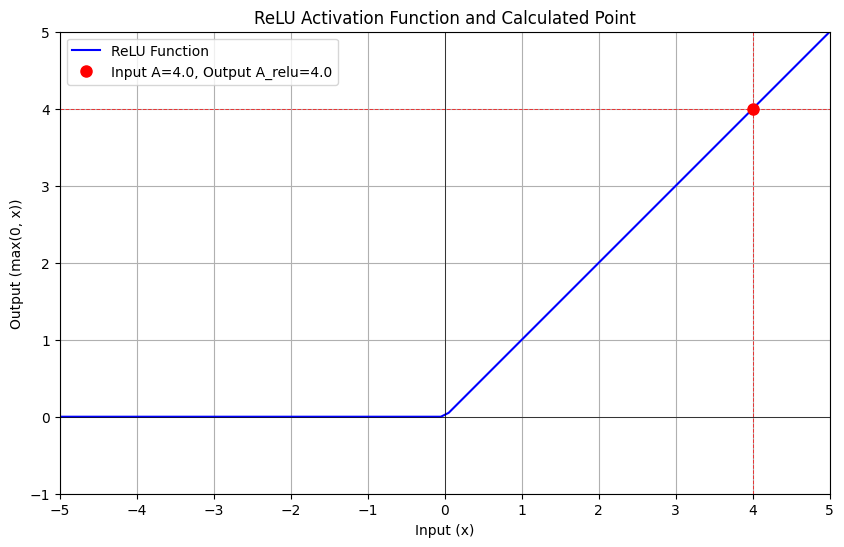

In [10]:
import matplotlib.pyplot as plt

# グラフ用にx軸の範囲を定義
x_values = np.linspace(-5, 5, 100)

# ReLU関数を適用
y_relu = relu(x_values)

plt.figure(figsize=(10, 6)) # アスペクト比に合わせて少し横長に
plt.plot(x_values, y_relu, label='ReLU Function', color='blue')

# 計算されたAとそのReLU後の値A_reluをプロット
plt.plot(A, A_relu, 'ro', markersize=8, label=f'Input A={A}, Output A_relu={A_relu}')

# Aが0より大きい場合、点線で入力と出力の関係を示す
if A > 0:
    plt.axvline(A, color='red', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.axhline(A_relu, color='red', linestyle='--', linewidth=0.7, alpha=0.7)

plt.title('ReLU Activation Function and Calculated Point')
plt.xlabel('Input (x)')
plt.ylabel('Output (max(0, x))')

# 縦軸と横軸の縮尺を揃える
plt.gca().set_aspect('equal', adjustable='box')

# 表示範囲と目盛りを設定（縦軸を-1〜5に変更）
plt.xlim(-5, 5)
plt.ylim(-1, 5)
plt.xticks(np.arange(-5, 6, 1))
plt.yticks(np.arange(-1, 6, 1))

plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

### ニューラルネットワークの順伝播 (Forward Propagation)

これまでのステップで1つのニューロンでの計算（入力と重みの内積＋バイアス）と、活性化関数（ReLU）を学びました。ニューラルネットワークは、これらのニューロンを複数並べて「層」を作り、それを重ねることで複雑な表現力を獲得します。

ここでは、以下のシンプルな3層構造（入力層・隠れ層・出力層）のネットワークの順伝播を実装してみましょう。

*   **入力層 (Input Layer):** 2つの値を持つデータ
*   **隠れ層 (Hidden Layer):** 3つのニューロン（活性化関数としてこれまでに定義した `relu` を使用）
*   **出力層 (Output Layer):** 2つのニューロン（今回はシンプルに活性化関数を適用せず、そのまま出力とします）

In [11]:
# 入力層 (例として2つの特徴量を持つデータ)
X_nn = np.array([1.0, 0.5])

# --- 隠れ層（第1層）の重みとバイアス ---
# X_nn(サイズ2)から3つのニューロンへつなぐため、重み行列は 2x3 のサイズになります。
W1 = np.array([[0.1, 0.3, 0.5],
               [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])

# 隠れ層の計算: 内積 + バイアス
A1 = np.dot(X_nn, W1) + B1

# 隠れ層の活性化関数: 先ほど作成したReLU関数を通す
Z1 = relu(A1)

# --- 出力層（第2層）の重みとバイアス ---
# 隠れ層の出力Z1(サイズ3)から2つのニューロンへつなぐため、重み行列は 3x2 のサイズになります。
W2 = np.array([[0.1, 0.4],
               [0.2, 0.5],
               [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

# 出力層の計算: 内積 + バイアス
A2 = np.dot(Z1, W2) + B2

# 出力（分類問題などの場合はここにSoftmax関数などを適用しますが、今回は恒等関数としてそのまま出力します）
Y = A2

# 結果の表示
print(f"入力 X: {X_nn}")
print(f"隠れ層の入力(活性化関数適用前) A1: {A1}")
print(f"隠れ層の出力(ReLU適用後) Z1: {Z1}")
print(f"最終出力 Y: {Y}")

入力 X: [1.  0.5]
隠れ層の入力(活性化関数適用前) A1: [0.3 0.7 1.1]
隠れ層の出力(ReLU適用後) Z1: [0.3 0.7 1.1]
最終出力 Y: [0.6  1.33]


### 重みの図解 (Network Graph)

先ほど定義した重み `W1` と `W2` が、各ニューロンをどのようにつないでいるかをネットワーク図で確認します。
* **丸（ノード）**: 各層のニューロンを表します。
* **線（エッジ）**: ニューロン間のつながり（重み）を表します。
* **線の数値**: 実際の重みの値（0.1〜0.6）です。線が太いほど値が大きいことを意味します。

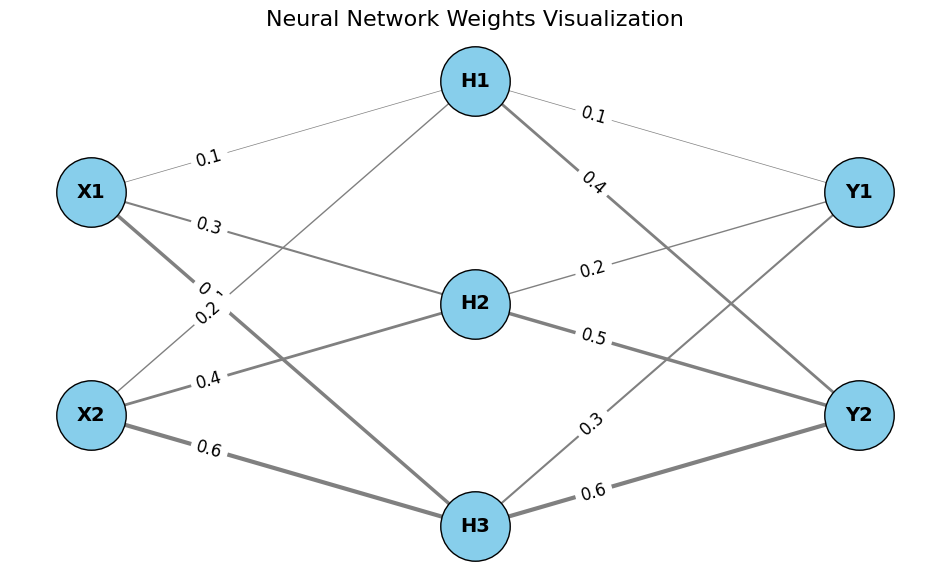

In [12]:
import matplotlib.pyplot as plt
import networkx as nx

# 有向グラフ（向きを持つグラフ）の作成
G = nx.DiGraph()

# 各ニューロンの配置座標を設定
pos = {
    'X1': (0, 1), 'X2': (0, -1),               # 入力層
    'H1': (1, 2), 'H2': (1, 0), 'H3': (1, -2), # 隠れ層
    'Y1': (2, 1), 'Y2': (2, -1)                # 出力層
}

# ネットワークの層の定義
inputs = ['X1', 'X2']
hiddens = ['H1', 'H2', 'H3']
outputs = ['Y1', 'Y2']

# エッジ（重み）を追加するリスト
edges = []

# W1の重みをグラフに追加
for i, in_node in enumerate(inputs):
    for j, out_node in enumerate(hiddens):
        weight = W1[i, j]
        G.add_edge(in_node, out_node, weight=weight)
        edges.append((in_node, out_node))

# W2の重みをグラフに追加
for i, in_node in enumerate(hiddens):
    for j, out_node in enumerate(outputs):
        weight = W2[i, j]
        G.add_edge(in_node, out_node, weight=weight)
        edges.append((in_node, out_node))

# 描画設定
plt.figure(figsize=(12, 7))

# ノード（ニューロン）の描画
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# エッジ（線）の太さを重みの大きさに比例させる
edge_widths = [G[u][v]['weight'] * 5 for u, v in edges]

# エッジの描画
nx.draw_networkx_edges(G, pos, edgelist=edges, width=edge_widths,
                       arrowstyle='->', arrowsize=20, edge_color='gray')

# エッジのラベル（重みの数値）を描画
edge_labels = {(u, v): f"{G[u][v]['weight']:.1f}" for u, v in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, label_pos=0.3)

plt.title("Neural Network Weights Visualization", fontsize=16)
plt.axis('off') # 軸を非表示にする
plt.show()

### 損失関数（誤差関数 / Loss Function）

順伝播によってネットワークの「予測値（出力 $Y$）」が得られました。しかし、最初はこの予測値はデタラメな値です。
ニューラルネットワークを賢くする（学習させる）ためには、**「実際の正解データ（$Y_{true}$）」と「予測値（$Y$）」がどれくらいズレているか（誤差）**を数値化する必要があります。このズレを計算する関数を**損失関数**と呼びます。

ネットワークの目的は、この「損失（Loss）」をできるだけ小さくするように、重みやバイアスを調整していくことです。

#### 代表的な損失関数：平均二乗誤差 (Mean Squared Error, MSE)
主に数値予測（回帰問題）で使われる最もシンプルな損失関数です。計算の手順は以下の通りです：
1.  予測値と正解の差（誤差）を計算する: $(Y - Y_{true})$
2.  その差を二乗する（マイナスの値をなくし、大きな誤差をより重く評価する）: $(Y - Y_{true})^2$
3.  すべての出力の二乗誤差の平均をとる: $\frac{1}{n} \sum (Y - Y_{true})^2$

In [13]:
# 正解データ (例として、期待される理想の出力が [1.0, 1.0] だったと仮定します)
Y_true = np.array([1.0, 1.0])

# 前のステップで計算したネットワークの出力 Y は [0.6, 1.33] でした。
print(f"予測値 Y: {Y}")
print(f"正解値 Y_true: {Y_true}\n")

# 1. 誤差（差）を計算
error = Y - Y_true
print(f"誤差 (Y - Y_true): {error}")

# 2. 誤差を二乗する
squared_error = error ** 2
print(f"二乗誤差: {squared_error}")

# 3. 平均をとる (MSE: 平均二乗誤差)
mse_loss = np.mean(squared_error)
print(f"\n最終的な損失 (MSE Loss): {mse_loss:.4f}")

# ※ この Loss (約 0.1344) を 0 に近づけていくのが「学習」のプロセスになります。

予測値 Y: [0.6  1.33]
正解値 Y_true: [1. 1.]

誤差 (Y - Y_true): [-0.4   0.33]
二乗誤差: [0.16   0.1089]

最終的な損失 (MSE Loss): 0.1344


### 誤差逆伝播法 (Backpropagation) の仕組み

損失関数（MSE）で求めた「誤差」を減らすためには、各重みやバイアスを少しずつ修正する必要があります。この「どちらの方向に、どれくらい修正すべきか」を表すのが**勾配（微分）**です。

誤差逆伝播法では、出力層から入力層へ向かって逆順に計算を行うことで、効率的にすべての重みの勾配を求めることができます。これは数学の**連鎖律（チェーンルール）**を利用しています。

#### 出力層の勾配計算
1.  **出力$Y$の勾配 ($dL/dY$)**: まず、損失$L$が予測値$Y$の変化によってどう変わるかを計算します。
2.  **重み$W2$の勾配 ($dL/dW2$)**: 次に、$dL/dY$ と隠れ層の出力$Z1$を使って、重み$W2$をどう修正すべきかを計算します。
3.  **バイアス$B2$の勾配 ($dL/dB2$)**: 同様に、$dL/dY$ を使ってバイアス$B2$の修正量を計算します。

In [14]:
# 1. 損失関数(MSE)の出力 Y に対する微分 (勾配)
# MSE = (1/N) * sum((Y - Y_true)^2)
# dL/dY = 2/N * (Y - Y_true)
N = len(Y)
dL_dY = (2 / N) * (Y - Y_true)
print(f"1. 損失の出力Yに対する勾配 (dL/dY):\n   {dL_dY}\n")

# 2. 出力層の重み W2 に対する勾配 (dL/dW2)
# Y = Z1・W2 + B2 の関係から、W2に関する微分は Z1 になります。
# 連鎖律により: dL/dW2 = Z1^T ・ dL/dY
# ※プログラム上は、Z1(サイズ3)とdL_dY(サイズ2)の外積をとり、3x2の行列を作ります
dL_dW2 = np.outer(Z1, dL_dY)
print(f"2. 重みW2の勾配 (dL/dW2):\n{dL_dW2}\n")

# 3. 出力層のバイアス B2 に対する勾配 (dL/dB2)
# Y = Z1・W2 + B2 の関係から、B2に関する微分は 1 になります。
# 連鎖律により: dL/dB2 = dL/dY
dL_dB2 = dL_dY
print(f"3. バイアスB2の勾配 (dL/dB2):\n   {dL_dB2}")

1. 損失の出力Yに対する勾配 (dL/dY):
   [-0.4   0.33]

2. 重みW2の勾配 (dL/dW2):
[[-0.12   0.099]
 [-0.28   0.231]
 [-0.44   0.363]]

3. バイアスB2の勾配 (dL/dB2):
   [-0.4   0.33]


#### 重みの更新 (最適化)

計算された勾配（`dL_dW2` や `dL_dB2`）は、「この方向に重みを動かすと誤差が増える」という方向を示しています。そのため、**勾配の逆方向**に重みを少しだけ動かすことで、誤差を小さくすることができます（これを**勾配降下法**と呼びます）。

```python
学習率 (learning_rate) = 0.01
新しい W2 = 現在の W2 - (学習率 * dL_dW2)
```
これを繰り返すことで、ニューラルネットワークは正解データに近づくように「学習」していきます。

In [15]:
# 学習率 (Learning Rate) の設定
# 1回の更新でどれくらいパラメータを動かすかを決めます
learning_rate = 0.1

print("--- 更新前 ---")
print(f"W2:\n{W2}")
print(f"B2: {B2}\n")

# 重みとバイアスの更新 (勾配降下法)
# パラメータ = 現在のパラメータ - (学習率 * 勾配)
W2_new = W2 - (learning_rate * dL_dW2)
B2_new = B2 - (learning_rate * dL_dB2)

print("--- 更新後 ---")
print(f"新しい W2:\n{W2_new}")
print(f"新しい B2: {B2_new}\n")

print("※勾配がマイナスだった部分は値が大きくなり、プラスだった部分は値が小さくなっていることが確認できます。")

--- 更新前 ---
W2:
[[0.1 0.4]
 [0.2 0.5]
 [0.3 0.6]]
B2: [0.1 0.2]

--- 更新後 ---
新しい W2:
[[0.112  0.3901]
 [0.228  0.4769]
 [0.344  0.5637]]
新しい B2: [0.14  0.167]

※勾配がマイナスだった部分は値が大きくなり、プラスだった部分は値が小さくなっていることが確認できます。


### 隠れ層への誤差逆伝播 (W1, B1の勾配計算)

隠れ層の重み（W1）とバイアス（B1）を更新するには、出力層で求まった誤差をさらに遡って伝播させる必要があります。ここでも**連鎖律（チェーンルール）**を利用します。

計算は以下の3つのステップで行います：

1. **隠れ層の出力に対する勾配 ($dL/dZ1$)**:
   出力層の誤差（`dL_dY`）が、重み `W2` を逆流して隠れ層にどのように影響するかを計算します。
2. **活性化関数（ReLU）の逆伝播 ($dL/dA1$)**:
   ReLU関数は順伝播の際、「入力が0より大きければそのまま通し、0以下なら0にする」という性質がありました。そのため、逆伝播（微分）でも**「順伝播時に入力が0より大きかったニューロンにだけ誤差をそのまま通し、それ以外は0（ストップ）にする」**というフィルターのような操作を行います。
3. **隠れ層の重みとバイアスの勾配 ($dL/dW1, dL/dB1$)**:
   入力 `X_nn` と求まった誤差 `$dL/dA1$` を使って、W1とB1それぞれの修正方向（勾配）を計算します。

In [16]:
# 1. 隠れ層の出力 Z1 に対する勾配 (dL/dZ1)
# 出力層の勾配(dL_dY)が、重みW2を逆向きにたどって伝わります。
# 数式: dL/dZ1 = W2 ・ dL_dY
dL_dZ1 = np.dot(W2, dL_dY)
print(f"1. 隠れ層の出力Z1に対する勾配 (dL/dZ1):\n   {dL_dZ1}\n")

# 2. 隠れ層の入力 A1 に対する勾配 (dL/dA1) : ReLUの微分（逆伝播）
# A1 > 0 のときは 1、A1 <= 0 のときは 0 となるような配列を作ります
relu_derivative = (A1 > 0).astype(float)
print(f"(参考) ReLUの微分フィルター: {relu_derivative}")

# フィルターを掛け合わせて、誤差を通すか止めるかを決定します
dL_dA1 = dL_dZ1 * relu_derivative
print(f"2. 隠れ層の入力A1に対する勾配 (dL/dA1):\n   {dL_dA1}\n")

# 3. 隠れ層の重み W1 に対する勾配 (dL/dW1)
# 数式: dL/dW1 = X_nn^T ・ dL_dA1 (外積)
dL_dW1 = np.outer(X_nn, dL_dA1)
print(f"3. 隠れ層の重みW1に対する勾配 (dL/dW1):\n{dL_dW1}\n")

# 4. 隠れ層のバイアス B1 に対する勾配 (dL/dB1)
# 数式: dL/dB1 = dL/dA1
dL_dB1 = dL_dA1
print(f"4. 隠れ層のバイアスB1に対する勾配 (dL/dB1):\n   {dL_dB1}\n")

# --- W1とB1の更新（勾配降下法） ---
print("-" * 30)
print("--- 隠れ層の重み・バイアス更新 ---")
W1_new = W1 - (learning_rate * dL_dW1)
B1_new = B1 - (learning_rate * dL_dB1)
print(f"更新前の W1:\n{W1}\n")
print(f"新しい W1:\n{W1_new}\n")
print(f"新しい B1:\n{B1_new}")


1. 隠れ層の出力Z1に対する勾配 (dL/dZ1):
   [0.092 0.085 0.078]

(参考) ReLUの微分フィルター: [1. 1. 1.]
2. 隠れ層の入力A1に対する勾配 (dL/dA1):
   [0.092 0.085 0.078]

3. 隠れ層の重みW1に対する勾配 (dL/dW1):
[[0.092  0.085  0.078 ]
 [0.046  0.0425 0.039 ]]

4. 隠れ層のバイアスB1に対する勾配 (dL/dB1):
   [0.092 0.085 0.078]

------------------------------
--- 隠れ層の重み・バイアス更新 ---
更新前の W1:
[[0.1 0.3 0.5]
 [0.2 0.4 0.6]]

新しい W1:
[[0.0908  0.2915  0.4922 ]
 [0.1954  0.39575 0.5961 ]]

新しい B1:
[0.0908 0.1915 0.2922]


### 学習ループ（エポック）の実行

ここまでのステップをすべてつなぎ合わせて、いよいよ完全な「学習ループ」を回してみましょう。

ニューラルネットワークの学習では、同じデータに対して何度も計算と更新を繰り返します。この学習の1サイクルのことを **エポック (Epoch)** と呼びます。

以下のコードでは、重みとバイアスを初期状態に戻した上で、学習を100エポック繰り返し、誤差（Loss）がどのように減っていくかをグラフ化します。

--- 学習スタート ---
Epoch  10/100 - Loss: 0.000407 - 予測Y: [0.9765, 1.0162]
Epoch  20/100 - Loss: 0.000001 - 予測Y: [0.9991, 1.0007]
Epoch  30/100 - Loss: 0.000000 - 予測Y: [1.0000, 1.0000]
Epoch  40/100 - Loss: 0.000000 - 予測Y: [1.0000, 1.0000]
Epoch  50/100 - Loss: 0.000000 - 予測Y: [1.0000, 1.0000]
Epoch  60/100 - Loss: 0.000000 - 予測Y: [1.0000, 1.0000]
Epoch  70/100 - Loss: 0.000000 - 予測Y: [1.0000, 1.0000]
Epoch  80/100 - Loss: 0.000000 - 予測Y: [1.0000, 1.0000]
Epoch  90/100 - Loss: 0.000000 - 予測Y: [1.0000, 1.0000]
Epoch 100/100 - Loss: 0.000000 - 予測Y: [1.0000, 1.0000]
--- 学習完了！ ---


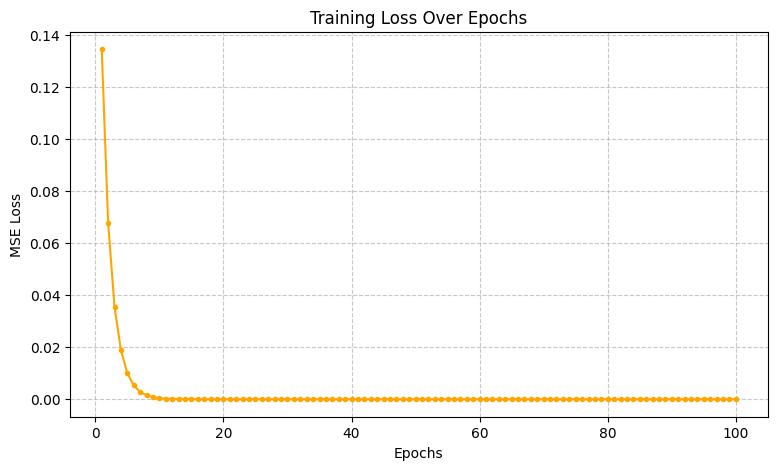

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. データの準備（おさらい）
X_nn = np.array([1.0, 0.5])
Y_true = np.array([1.0, 1.0])

# 2. パラメータの初期化（学習を最初から見直すため、初期値に戻します）
W1 = np.array([[0.1, 0.3, 0.5],
               [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])
W2 = np.array([[0.1, 0.4],
               [0.2, 0.5],
               [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

# 学習の設定
learning_rate = 0.1
epochs = 100 # 繰り返す回数

# 誤差の推移を記録するリスト
loss_history = []

print("--- 学習スタート ---")
for epoch in range(epochs):
    # === ① 順伝播 (Forward Propagation) ===
    A1 = np.dot(X_nn, W1) + B1
    Z1 = relu(A1)  # 隠れ層の活性化関数
    A2 = np.dot(Z1, W2) + B2
    Y_pred = A2    # 予測値

    # === ② 損失の計算 (MSE Loss) ===
    error = Y_pred - Y_true
    mse_loss = np.mean(error ** 2)
    loss_history.append(mse_loss)

    # === ③ 逆伝播 (Backpropagation) ===
    N = len(Y_pred)
    # 出力層の勾配計算
    dL_dY = (2 / N) * error
    dL_dW2 = np.outer(Z1, dL_dY)
    dL_dB2 = dL_dY

    # 隠れ層の勾配計算
    dL_dZ1 = np.dot(W2, dL_dY)
    relu_derivative = (A1 > 0).astype(float)
    dL_dA1 = dL_dZ1 * relu_derivative
    dL_dW1 = np.outer(X_nn, dL_dA1)
    dL_dB1 = dL_dA1

    # === ④ 重みとバイアスの更新 (Gradient Descent) ===
    W2 -= learning_rate * dL_dW2
    B2 -= learning_rate * dL_dB2
    W1 -= learning_rate * dL_dW1
    B1 -= learning_rate * dL_dB1

    # 10エポックごとに途中経過を表示
    if (epoch + 1) % 10 == 0:
        # 予測値の見た目を整えて表示
        pred_str = f"[{Y_pred[0]:.4f}, {Y_pred[1]:.4f}]"
        print(f"Epoch {epoch + 1:3d}/{epochs} - Loss: {mse_loss:.6f} - 予測Y: {pred_str}")

print("--- 学習完了！ ---")

# === ⑤ 学習の推移をグラフで表示 ===
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o', markersize=3, color='orange')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 複数データへの対応と学習曲線 (Learning Curve)

より実践に近い形でニューラルネットワークを訓練します。

1. **データの複数化（バッチ化）**: 100個のデータを作成し、行列計算を使って一気に処理します。
2. **データの分割**: 80個を「訓練セット（学習用）」、20個を「テストセット（答え合わせ用）」に分けます。過学習がおきる条件（訓練データが10個）も試します。
3. **過学習の確認**: 訓練セットの誤差だけでなく、テストセットの誤差も同時にグラフ（学習曲線）に描画することで、AIが「丸暗記（過学習）」せず未知のデータにも対応できているかを確認します。

正常な学習（訓練データ80個）を実行中...
過学習（訓練データ10個）を実行中...
--- 学習完了！ ---


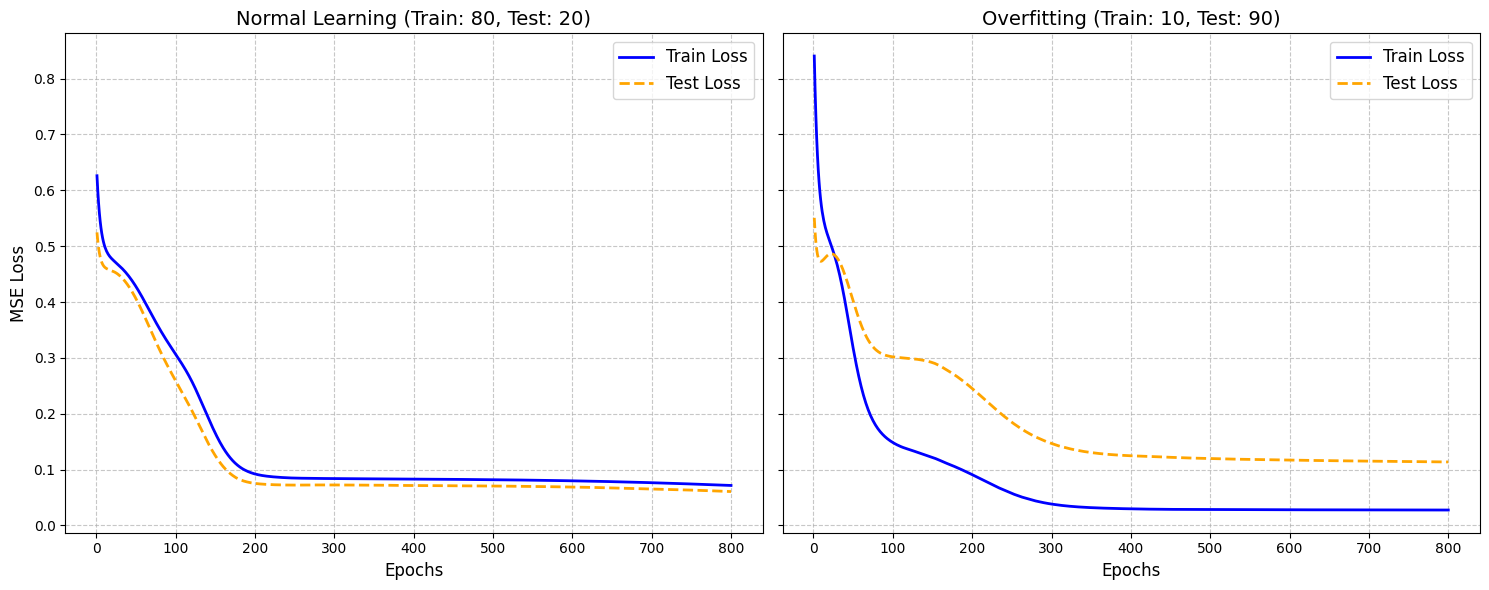

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. データセットの作成 ---
np.random.seed(42)
num_samples = 100
X_all = np.random.rand(num_samples, 2) * 2 - 1
Y_all = np.zeros((num_samples, 2))
Y_all[:, 0] = X_all[:, 0]**2 + X_all[:, 1]
Y_all[:, 1] = X_all[:, 0] - X_all[:, 1]**2

# --- 2. 学習を行う関数 ---
# 条件（訓練データの数）を変えて何度でも実行できるように関数化します
def train_model(split_idx, epochs=800):
    # データの分割
    X_train, X_test = X_all[:split_idx], X_all[split_idx:]
    Y_train, Y_test = Y_all[:split_idx], Y_all[split_idx:]

    # パラメータの初期化 (毎回同じ初期値からスタートするためシードを固定)
    np.random.seed(42)
    W1 = np.random.randn(2, 3) * 0.1
    B1 = np.zeros(3)
    W2 = np.random.randn(3, 2) * 0.1
    B2 = np.zeros(2)

    learning_rate = 0.05
    train_loss_history = []
    test_loss_history = []

    for epoch in range(epochs):
        # 順伝播 (Train)
        A1_train = np.dot(X_train, W1) + B1
        Z1_train = relu(A1_train)
        A2_train = np.dot(Z1_train, W2) + B2

        # Loss計算 (Train)
        error_train = A2_train - Y_train
        train_loss_history.append(np.mean(error_train ** 2))

        # 逆伝播 (Train)
        N = len(X_train)
        dL_dY = (2 / N) * error_train
        dL_dW2 = np.dot(Z1_train.T, dL_dY)
        dL_dB2 = np.sum(dL_dY, axis=0)
        dL_dZ1 = np.dot(dL_dY, W2.T)
        dL_dA1 = dL_dZ1 * (A1_train > 0).astype(float)
        dL_dW1 = np.dot(X_train.T, dL_dA1)
        dL_dB1 = np.sum(dL_dA1, axis=0)

        # パラメータ更新
        W2 -= learning_rate * dL_dW2
        B2 -= learning_rate * dL_dB2
        W1 -= learning_rate * dL_dW1
        B1 -= learning_rate * dL_dB1

        # テストデータでの評価 (学習には使わない)
        A1_test = np.dot(X_test, W1) + B1
        Z1_test = relu(A1_test)
        A2_test = np.dot(Z1_test, W2) + B2
        error_test = A2_test - Y_test
        test_loss_history.append(np.mean(error_test ** 2))

    return train_loss_history, test_loss_history

# --- 3. 2つの条件で学習を実行 ---
epochs_count = 800
print("正常な学習（訓練データ80個）を実行中...")
train_loss_norm, test_loss_norm = train_model(split_idx=80, epochs=epochs_count)

print("過学習（訓練データ10個）を実行中...")
train_loss_over, test_loss_over = train_model(split_idx=10, epochs=epochs_count)

print("--- 学習完了！ ---")

# --- 4. 学習曲線の比較描画 ---
# sharey=True を指定して、左右のグラフの縦軸のスケールを揃えます
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# 左側のグラフ：正常な学習
ax1.plot(range(1, epochs_count + 1), train_loss_norm, label='Train Loss', color='blue', linewidth=2)
ax1.plot(range(1, epochs_count + 1), test_loss_norm, label='Test Loss', color='orange', linewidth=2, linestyle='--')
ax1.set_title("Normal Learning (Train: 80, Test: 20)", fontsize=14)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("MSE Loss", fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# 右側のグラフ：過学習
ax2.plot(range(1, epochs_count + 1), train_loss_over, label='Train Loss', color='blue', linewidth=2)
ax2.plot(range(1, epochs_count + 1), test_loss_over, label='Test Loss', color='orange', linewidth=2, linestyle='--')
ax2.set_title("Overfitting (Train: 10, Test: 90)", fontsize=14)
ax2.set_xlabel("Epochs", fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### 入出力データの可視化 (散布図)

学習に使用したデータセット（入力 $X$ と正解出力 $Y$）の分布を散布図で確認します。
入力データが、数式 ($Y_1 = X_1^2 + X_2$, $Y_2 = X_1 - X_2^2$) によってどのように変換されているかを視覚的に捉えることができます。

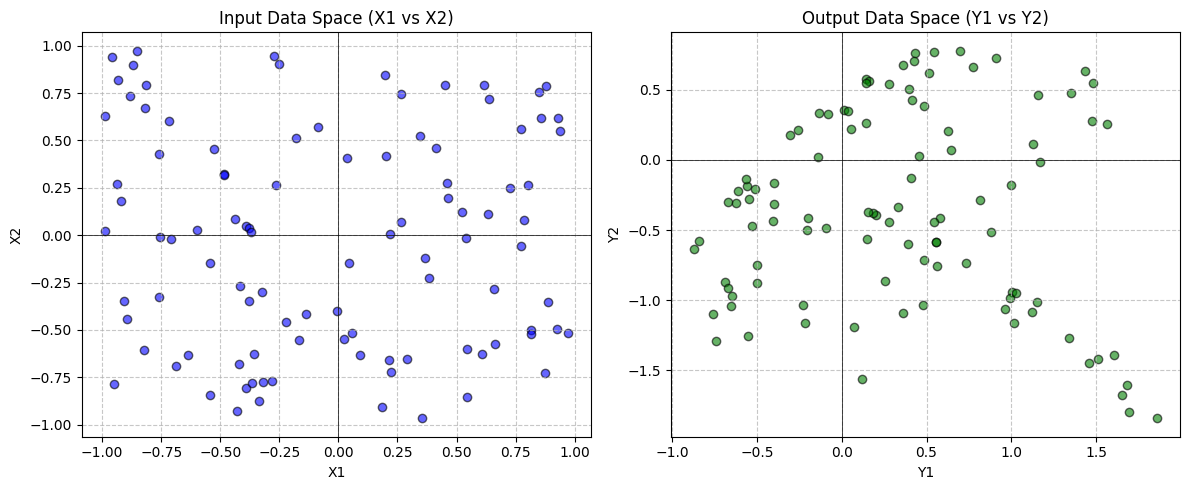

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1つ目のグラフ: 入力データ(X)の分布
plt.subplot(1, 2, 1)
plt.scatter(X_all[:, 0], X_all[:, 1], c='blue', alpha=0.6, edgecolors='k')
plt.title("Input Data Space (X1 vs X2)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# 2つ目のグラフ: 出力データ(Y)の分布
plt.subplot(1, 2, 2)
plt.scatter(Y_all[:, 0], Y_all[:, 1], c='green', alpha=0.6, edgecolors='k')
plt.title("Output Data Space (Y1 vs Y2)")
plt.xlabel("Y1")
plt.ylabel("Y2")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


### 入力から出力への変換の軌跡（対応線の描画）

入力データ（青い丸）が、どのような軌跡をたどって出力データ（緑の星）へと変換されたのかを、同じグラフ上に重ねて線で結ぶことで確認します。

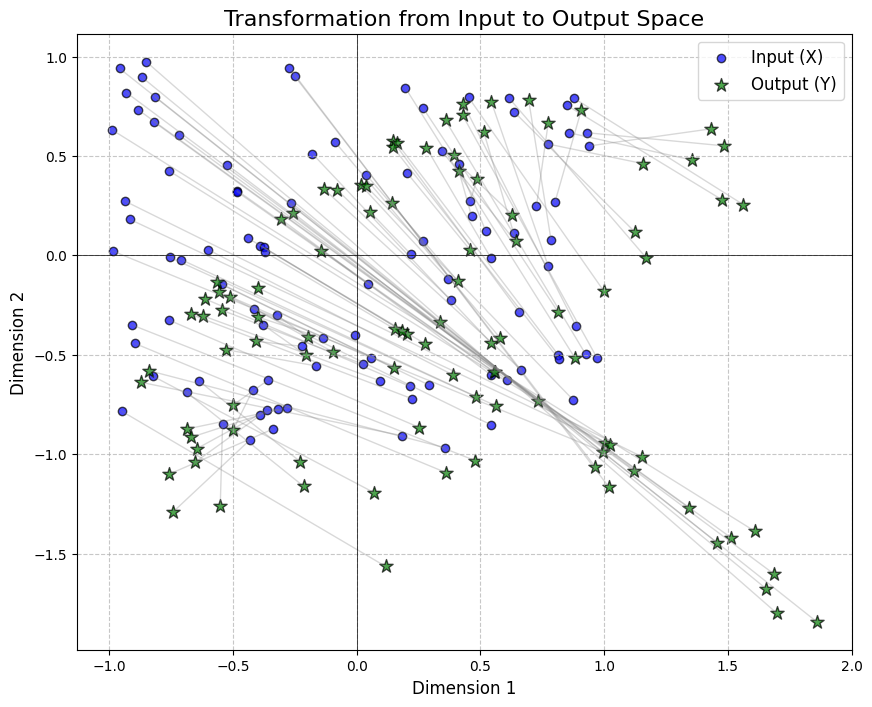

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# 各データポイントについて、入力(X)から出力(Y)への線を引く
for i in range(num_samples):
    plt.plot([X_all[i, 0], Y_all[i, 0]], [X_all[i, 1], Y_all[i, 1]],
             color='gray', alpha=0.3, linewidth=1)

# 入力データを青い丸でプロット
plt.scatter(X_all[:, 0], X_all[:, 1], c='blue', alpha=0.7, edgecolors='k', label='Input (X)')

# 出力データを緑の星でプロット（少し大きめにする）
plt.scatter(Y_all[:, 0], Y_all[:, 1], c='green', marker='*', s=100, alpha=0.7, edgecolors='k', label='Output (Y)')

plt.title("Transformation from Input to Output Space", fontsize=16)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend(fontsize=12)
plt.show()

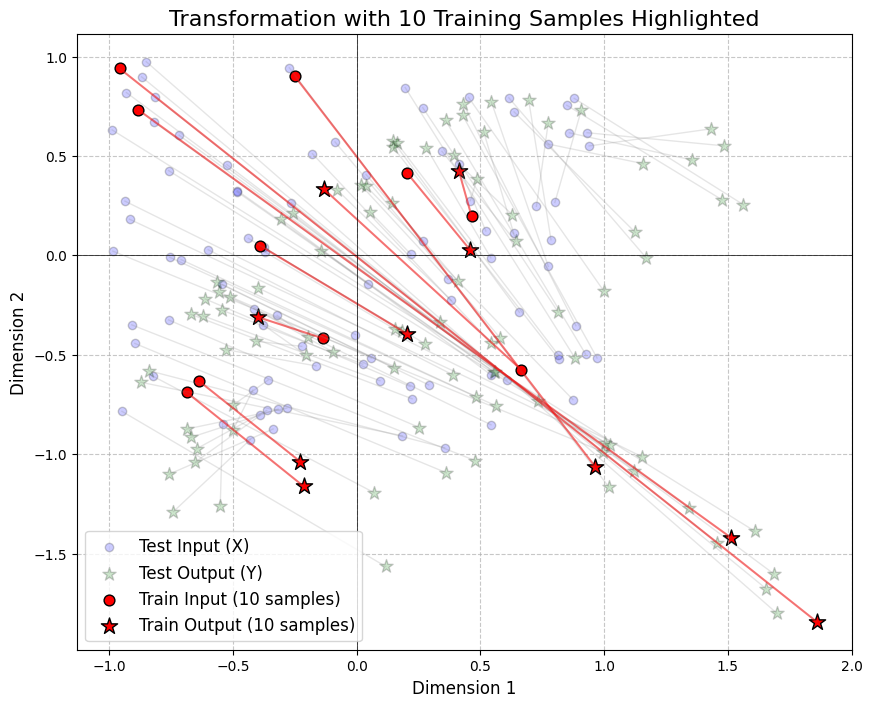

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# 1. 全データの線を引く（薄いグレー）
for i in range(num_samples):
    plt.plot([X_all[i, 0], Y_all[i, 0]], [X_all[i, 1], Y_all[i, 1]],
             color='gray', alpha=0.2, linewidth=1)

# 2. 訓練データ(10個)の線を引く（赤色で少し太く）
for i in range(10):
    plt.plot([X_all[i, 0], Y_all[i, 0]], [X_all[i, 1], Y_all[i, 1]],
             color='red', alpha=0.5, linewidth=1.5)

# 3. 全てのデータを薄い色でプロット
plt.scatter(X_all[:, 0], X_all[:, 1], c='blue', alpha=0.2, edgecolors='k', label='Test Input (X)')
plt.scatter(Y_all[:, 0], Y_all[:, 1], c='green', marker='*', s=100, alpha=0.2, edgecolors='k', label='Test Output (Y)')

# 4. 訓練データ(10個)を赤色で強調表示
plt.scatter(X_all[:10, 0], X_all[:10, 1], c='red', s=60, alpha=1.0, edgecolors='k', label='Train Input (10 samples)')
plt.scatter(Y_all[:10, 0], Y_all[:10, 1], c='red', marker='*', s=150, alpha=1.0, edgecolors='k', label='Train Output (10 samples)')

plt.title("Transformation with 10 Training Samples Highlighted", fontsize=16)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend(fontsize=12)
plt.show()


### Pytorchを使用するメリットとデメリット

これまでNumPyを使ってゼロから実装してきたニューラルネットワークですが、実務や研究ではおっしゃる通り **PyTorch**（や TensorFlow）といったディープラーニング用フレームワークを使うのが一般的です。

#### 🌟 メリット (PyTorchを使う理由)

1. **自動微分（Autograd）機能**
   - **最大のメリット**です。今回、誤差逆伝播法（バックプロパゲーション）のために偏微分の数式を自分で計算し、コードに落とし込みました（`dL_dW1 = ...` など）。PyTorchを使えば、順伝播（フォワード）の計算を書くだけで、**逆伝播の微分計算をAIが自動で行ってくれます**。これにより、複雑なネットワークでも数学的なミスなく一瞬で勾配を求められます。
2. **GPUによる高速計算**
   - 行列計算をCPUではなくGPU（グラフィックボード）で処理できます。NumPyはCPUを使いますが、PyTorchは `.to('cuda')` と書くだけで計算をGPUに投げることができ、大規模なデータや巨大なAIモデルの学習スピードが劇的に向上します。
3. **豊富な最適化手法とレイヤーの提供**
   - 今回は単純な「勾配降下法」と「ReLU」を実装しましたが、PyTorchにはより賢く学習を進めるアルゴリズム（Adamなど）や、多様な層（畳み込み層、Attention層など）があらかじめ用意されており、ブロックを組み立てるように高度なAIを作れます。

#### ⚠️ デメリット（注意点）

1. **「ブラックボックス化」しやすい**
   - 自動で何でもやってくれるため、中でどのような数学的計算（微分の連鎖律など）が行われているかを理解していなくてもAIが作れてしまいます。そのため、エラーが出た時やモデルが学習しない時に、原因を特定して修正する応用力が身につきにくくなります。（だからこそ、今回のようにNumPyで基礎を実装した経験が後々大きな武器になります！）
2. **独自の記法やルールの学習が必要**
   - NumPyの `ndarray` ではなく PyTorchの `Tensor` という独自のデータ型を使う必要があり、データの扱い方（DataLoaderなど）や学習ループの書き方に独特の「お作法」があります。学習コストが少しかかります。
3. **環境構築とデータサイズ**
   - PyTorch自体が非常に容量の大きいライブラリであり、ローカルPCでGPUを動かすための環境構築（CUDAの設定など）でつまずく初心者が多いです。（Google Colabを使えばこの問題はほぼ解決します）

**まとめ:**
基礎の理解（数学的背景やアルゴリズムの仕組み）には今回のような**NumPyによるスクラッチ実装**が最適ですが、実際のアプリケーション開発や最新の複雑なAIモデルを作るフェーズでは、**PyTorch**の生産性と計算パワーが必須になります。

### Pytorch版

PyTorchを使って、今回と同じ構造のニューラルネットワーク（入力層2・隠れ層3・出力層2）と学習ループを記述しました。

PyTorchの nn.Linear を使うと重みとバイアスが自動で用意され、loss.backward() を呼ぶだけで先ほど長々と書いた逆伝播の勾配計算をすべて自動で行ってくれます！

コードが無事に実行されました！PyTorchを使った学習でも、NumPyで書いた時と同じようにLoss（誤差）がスムーズに0へと収束し、最終予測値も正解である [1.0, 1.0] に極めて近い値になっていることが確認できます。

途中の複雑な偏微分の計算（dL_dW1 など）を loss.backward() というたった1行で済ませられるのは、PyTorchのようなフレームワークの大きな強みですね。

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. データの準備 (NumPy配列ではなくPyTorchのTensorを使用します)
X_train = torch.tensor([[1.0, 0.5]], dtype=torch.float32)
Y_true = torch.tensor([[1.0, 1.0]], dtype=torch.float32)

# 2. ネットワークの定義
class SimpleNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # 入力層(2) -> 隠れ層(3)
        self.fc1 = nn.Linear(in_features=2, out_features=3)
        # 隠れ層(3) -> 出力層(2)
        self.fc2 = nn.Linear(in_features=3, out_features=2)

    def forward(self, x):
        # 順伝播の計算手順を記述します
        x = self.fc1(x)
        x = torch.relu(x)  # 隠れ層の活性化関数
        x = self.fc2(x)
        return x

# モデルのインスタンス化
model = SimpleNetwork()

# 3. 損失関数と最適化手法(オプティマイザ)の定義
criterion = nn.MSELoss()  # 平均二乗誤差
optimizer = optim.SGD(model.parameters(), lr=0.1)  # 勾配降下法 (学習率0.1)

# 4. 学習ループ
epochs = 100
print("--- 学習スタート (PyTorch) ---")
for epoch in range(epochs):
    # ① 勾配をリセット (毎エポック必須)
    optimizer.zero_grad()

    # ② 順伝播 (予測値の計算)
    Y_pred = model(X_train)

    # ③ 損失の計算
    loss = criterion(Y_pred, Y_true)

    # ④ 逆伝播 (自動微分！自分で数式を書く必要はありません)
    loss.backward()

    # ⑤ 重みとバイアスの更新
    optimizer.step()

    # 10エポックごとに経過を表示
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1:3d}/{epochs} - Loss: {loss.item():.6f}")

print("--- 学習完了！ ---")
print(f"最終予測値: {Y_pred.detach().numpy()[0]}")

--- 学習スタート (PyTorch) ---
Epoch  10/100 - Loss: 0.002398
Epoch  20/100 - Loss: 0.000001
Epoch  30/100 - Loss: 0.000000
Epoch  40/100 - Loss: 0.000000
Epoch  50/100 - Loss: 0.000000
Epoch  60/100 - Loss: 0.000000
Epoch  70/100 - Loss: 0.000000
Epoch  80/100 - Loss: 0.000000
Epoch  90/100 - Loss: 0.000000
Epoch 100/100 - Loss: 0.000000
--- 学習完了！ ---
最終予測値: [0.99999994 0.9999999 ]
